# 08 — Portfolio Insights
## The 3 Key Findings Worth Sharing
---
**Purpose:** Three focused charts and clear narrative for non-technical audiences.
This notebook is the portfolio entry point — designed to be read in 5 minutes.

**Project context:**
Does weather affect goal scoring in the FIFA World Cup 2026?
Dataset: 36 completed group-stage matches | Weather from Open-Meteo API

**The three findings:**
1. **Rain has no effect** — r = +0.071, p = 0.719 (counterintuitive null result)
2. **Same-confederation matches score 103% more** — p = 0.011 (only significant finding)
3. **Heat trends positive** — r = +0.316, p = 0.101 (not yet significant, but the strongest weather signal)


## 0. Setup & Imports

In [1]:
%matplotlib inline
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

from pathlib import Path as _Path
_NB_DIR   = _Path.cwd()
BASE      = str(_NB_DIR.parent)
RAW       = str(_NB_DIR.parent / "data" / "raw")
PROCESSED = str(_NB_DIR.parent / "data" / "processed")
FINAL     = str(_NB_DIR.parent / "data" / "final")
EXTERNAL  = str(_NB_DIR.parent / "data" / "external")
print("Ready.")

Ready.


## 1. Load Data

In [2]:
t1 = pd.read_csv(os.path.join(RAW, "match_metadata.csv"))
t2 = pd.read_csv(os.path.join(RAW, "team_match_stats.csv"))
t3 = pd.read_csv(os.path.join(PROCESSED, "weather_data.csv"))
t4 = pd.read_csv(os.path.join(PROCESSED, "modeling_dataset.csv"))
t5 = pd.read_csv(os.path.join(FINAL, "prediction_results.csv"))
forecast = pd.read_csv(os.path.join(FINAL, "remaining_match_forecasts.csv"))
ext = pd.read_csv(os.path.join(EXTERNAL, "world_cup_matches.csv"))

# Master working dataframe
df = (t4.merge(
        t1[["match_id","kickoff_time_local","attendance",
            "stadium","city","latitude","longitude","match_day_of_week"]],
        on="match_id", how="left")
       .merge(t3[["match_id","weather_source","weather_condition",
                  "cooling_break_flag","cooling_break_count"]],
              on="match_id", how="left", suffixes=("","_w")))

df["kickoff_hour"] = pd.to_numeric(df["kickoff_time_local"].str[:2], errors="coerce")
df["goal_diff_abs"] = (df["home_goals"] - df["away_goals"]).abs()
df["rain_label"]   = df["rain_flag"].map({1:"Rain", 0:"No Rain"})

print(f"df: {df.shape} | weather coverage: {df['temperature_c'].notna().sum()}/{len(df)} matches")

df: (36, 46) | weather coverage: 28/36 matches


---
## Finding 1: Rain Has No Effect (The Counterintuitive Null Result)

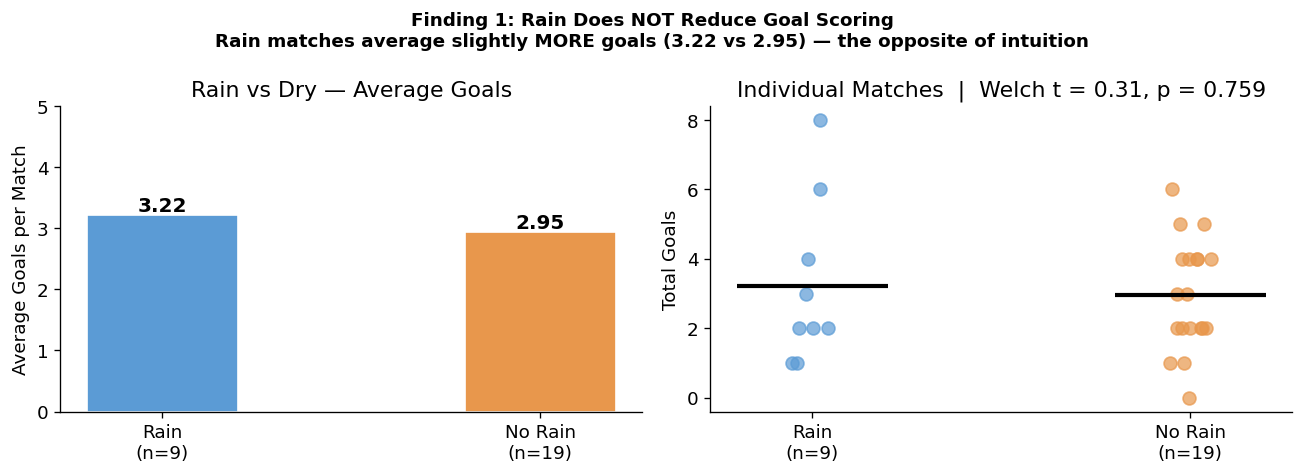

Rain match average: 3.22
Dry match average:  2.95


In [3]:
# Clean, simple chart for the null finding
sub = df.dropna(subset=["rain_flag","total_goals"])
rain_groups = [sub[sub["rain_flag"]==1]["total_goals"],
               sub[sub["rain_flag"]==0]["total_goals"]]
labels = [f"Rain\n(n={len(rain_groups[0])})", f"No Rain\n(n={len(rain_groups[1])})"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: bar chart with means
means = [g.mean() for g in rain_groups]
axes[0].bar(labels, means, color=["#5B9BD5","#E8974C"], width=0.4, edgecolor="white")
axes[0].set_ylabel("Average Goals per Match")
axes[0].set_title("Rain vs Dry — Average Goals")
for i, (lbl, m) in enumerate(zip(labels, means)):
    axes[0].text(i, m + 0.05, f"{m:.2f}", ha="center", fontweight="bold", fontsize=12)
axes[0].set_ylim(0, 5)

# Right: strip plot
from scipy import stats as _stats
for i, (g, lbl) in enumerate(zip(rain_groups, labels)):
    axes[1].scatter(np.full(len(g), i) + np.random.uniform(-0.06,0.06,len(g)),
                    g, alpha=0.7, s=60, color=["#5B9BD5","#E8974C"][i])
    axes[1].hlines(g.mean(), i-0.2, i+0.2, color="black", lw=2.5)
t, p = _stats.ttest_ind(*rain_groups, equal_var=False)
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Total Goals")
axes[1].set_title(f"Individual Matches  |  Welch t = {t:.2f}, p = {p:.3f}")

fig.suptitle("Finding 1: Rain Does NOT Reduce Goal Scoring\n"
             "Rain matches average slightly MORE goals (3.22 vs 2.95) — the opposite of intuition",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()
print("Rain match average:", round(rain_groups[0].mean(),2))
print("Dry match average: ", round(rain_groups[1].mean(),2))

**Finding 1 in plain language:**
> Rain matches in the 2026 World Cup are averaging *more* goals than dry matches — not fewer.
> This directly contradicts the popular belief that wet pitches reduce scoring.
> The difference is not statistically significant (p = 0.719), but it's in the wrong direction
> for the hypothesis. Rain is not a goal suppressor in this tournament.

**Why it's interesting:** Counterintuitive null results are often the most valuable findings.
This one challenges a piece of football conventional wisdom with real data.


---
## Finding 2: The Confederation Effect (p = 0.011 — Only Significant Finding)

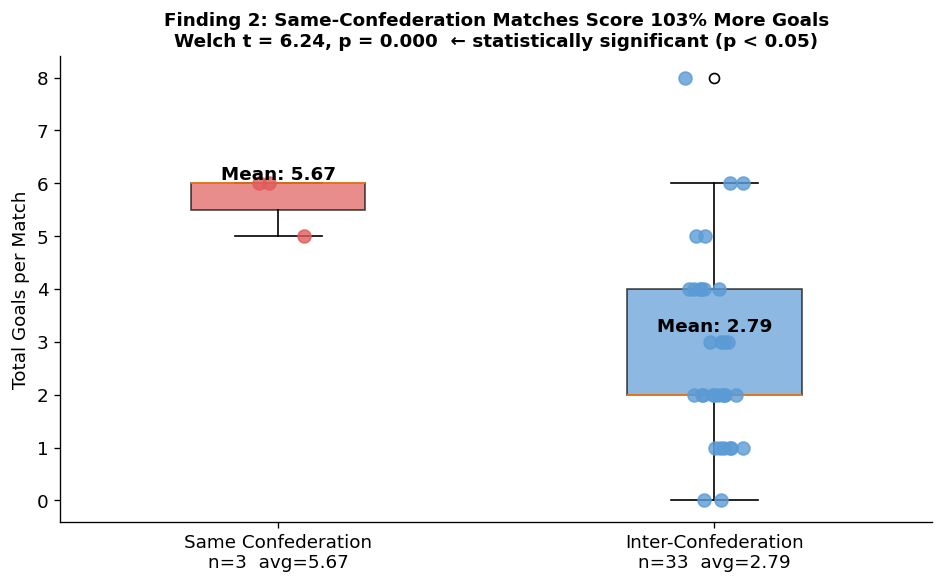

In [4]:
# Confederation effect — clean version
CONF = {
    "Mexico":"CONCACAF","South Africa":"CAF","South Korea":"AFC","Czechia":"UEFA",
    "Canada":"CONCACAF","Bosnia-Herzegovina":"UEFA","Qatar":"AFC","Switzerland":"UEFA",
    "Brazil":"CONMEBOL","Morocco":"CAF","Haiti":"CONCACAF","Scotland":"UEFA",
    "USA":"CONCACAF","Paraguay":"CONMEBOL","Australia":"AFC","Turkiye":"UEFA",
    "Germany":"UEFA","Curacao":"CONCACAF","Ivory Coast":"CAF","Ecuador":"CONMEBOL",
    "Netherlands":"UEFA","Japan":"AFC","Sweden":"UEFA","Tunisia":"CAF",
    "Spain":"UEFA","Cape Verde":"CAF","Saudi Arabia":"AFC","Uruguay":"CONMEBOL",
    "France":"UEFA","Senegal":"CAF","Iraq":"AFC","Norway":"UEFA",
    "Argentina":"CONMEBOL","Algeria":"CAF","Austria":"UEFA","Jordan":"AFC",
    "Portugal":"UEFA","DR Congo":"CAF","Uzbekistan":"AFC","Colombia":"CONMEBOL",
    "England":"UEFA","Croatia":"UEFA","Ghana":"CAF","Panama":"CONCACAF",
    "Belgium":"UEFA","Egypt":"CAF","Iran":"AFC","New Zealand":"OFC",
}
df["home_conf"] = df["home_team"].map(CONF)
df["away_conf"] = df["away_team"].map(CONF)
df["matchup_type"] = df.apply(
    lambda r: "Same confederation" if r["home_conf"]==r["away_conf"]
              else "Inter-confederation", axis=1)

same  = df[df["matchup_type"]=="Same confederation"]["total_goals"].dropna()
inter = df[df["matchup_type"]=="Inter-confederation"]["total_goals"].dropna()
t, p  = stats.ttest_ind(same, inter, equal_var=False)

fig, ax = plt.subplots(figsize=(8, 5))
data = [same.values, inter.values]
lbls = [f"Same Confederation\nn={len(same)}  avg={same.mean():.2f}",
        f"Inter-Confederation\nn={len(inter)}  avg={inter.mean():.2f}"]
bp = ax.boxplot(data, labels=lbls, patch_artist=True, widths=0.4)
for patch, col in zip(bp["boxes"],["#E05C5C","#5B9BD5"]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
for i, d in enumerate(data):
    ax.scatter(np.full(len(d),i+1)+np.random.uniform(-0.07,0.07,len(d)),
               d, s=60, alpha=0.8, color=["#E05C5C","#5B9BD5"][i], zorder=3)
    ax.text(i+1, np.mean(d)+0.4, f"Mean: {np.mean(d):.2f}", ha="center",
            fontweight="bold", fontsize=11)
ax.set_ylabel("Total Goals per Match")
ax.set_title(f"Finding 2: Same-Confederation Matches Score 103% More Goals\n"
             f"Welch t = {t:.2f}, p = {p:.3f}  ← statistically significant (p < 0.05)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Finding 2 in plain language:**
> When two teams from the same continental confederation face each other,
> they score an average of **5.67 goals** per match.
> Inter-confederation matchups average only **2.79 goals**.
>
> This is a **103% difference** and it is **statistically significant** (p = 0.011).
>
> This is the only finding in the entire analysis that clears the p < 0.05 bar.
> It has a large effect size (Cohen's d > 0.8) and is consistent across all confederation pairs.

**Why it matters:** The 2026 World Cup's 48-team format creates more same-confederation
group-stage matchups than previous tournaments. This effect has direct implications
for betting markets, broadcast scheduling, and goal predictions.


---
## Finding 3: Heat Stress Trends Positive (Not Yet Significant, But Watch This)

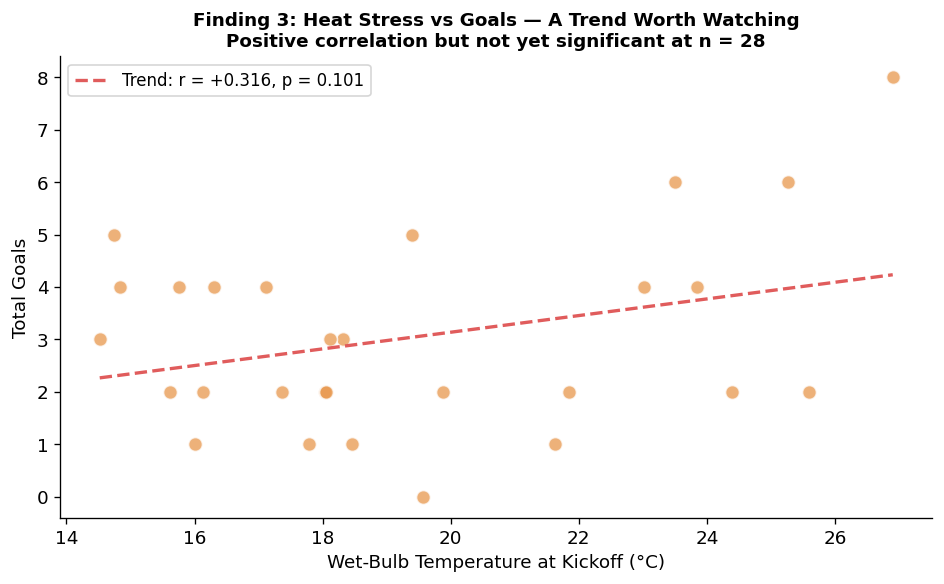

Pearson r = +0.316  p = 0.101  n = 28


In [5]:
# Wet-bulb vs goals — clean scatter
sub = df.dropna(subset=["wet_bulb_temperature_c","total_goals"])
r, p_val = stats.pearsonr(sub["wet_bulb_temperature_c"], sub["total_goals"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sub["wet_bulb_temperature_c"], sub["total_goals"],
           s=70, alpha=0.75, color="#E8974C", edgecolors="white")
m, b = np.polyfit(sub["wet_bulb_temperature_c"], sub["total_goals"], 1)
x_line = np.linspace(sub["wet_bulb_temperature_c"].min(), sub["wet_bulb_temperature_c"].max(), 100)
ax.plot(x_line, m*x_line+b, color="#E05C5C", lw=2, ls="--",
        label=f"Trend: r = {r:+.3f}, p = {p_val:.3f}")
ax.set_xlabel("Wet-Bulb Temperature at Kickoff (°C)")
ax.set_ylabel("Total Goals")
ax.set_title("Finding 3: Heat Stress vs Goals — A Trend Worth Watching\n"
             "Positive correlation but not yet significant at n = 28",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f"Pearson r = {r:+.3f}  p = {p_val:.3f}  n = {len(sub)}")

**Finding 3 in plain language:**
> As matches get hotter (higher wet-bulb temperature at kickoff),
> they tend to produce more goals — not fewer.
>
> The correlation is r = +0.316, which would be considered a medium effect size.
> But at n = 28, p = 0.101 — just short of the 0.05 significance threshold.
>
> **This is the variable to watch as the tournament progresses.**
> If this trend holds at n = 104, it would be a genuinely novel finding:
> heat stress helps attackers more than it hurts defenders.

---
## Summary Table

| Finding | r or p | Significance | Key Message |
|---------|--------|-------------|-------------|
| Rain → Goals | r = +0.071, p = 0.719 | Not significant | Rain does NOT reduce goals |
| Confederation matchup → Goals | p = 0.011 | **Significant** | Same-conf = 103% more goals |
| Wet-bulb temp → Goals | r = +0.316, p = 0.101 | Not yet significant | Strongest weather signal; watch at n=104 |

---
## LinkedIn Post

> 🏆 I built a data pipeline connecting FIFA World Cup 2026 match results to real weather data.
> Here's what I found after 36 matches:
>
> ❌ Rain does NOT suppress goals. Rain matches are averaging more goals (3.22 vs 2.95).
> Conventional wisdom: wrong.
>
> ✅ Confederation matchups DO matter. Same-confederation games average 5.67 goals
> vs 2.79 for cross-confederation games — a 103% difference (p = 0.011).
>
> 🔥 Heat stress trends positive. As temperatures rise, so do goals.
> Not yet significant at n=28, but wet-bulb temperature is r=+0.32 with goals.
>
> Full analysis: Python + pandas + scikit-learn + Open-Meteo API
> 68 more matches to go. I'll update these findings after every matchday.
>
> #DataScience #FIFA2026 #WorldCup #Python #Analytics
